<a href="https://colab.research.google.com/github/senapathi402-star/Netflix_case_study/blob/main/Netflix_Case_Study.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**NETFLIX**
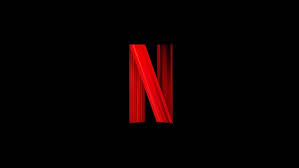

Netflix is an American subscription video on-demand over-the-top streaming service. The service primarily distributes original and acquired films and television shows from various genres, and it is available internationally in multiple languages.

**Importing the data**

In [1]:
import pandas as pd
!gdown 1Rfubz9-Cn-WXL7qMd79fwNN4vI1TidB7
df=pd.read_csv('/content/netlix_class' , index_col=0)

Downloading...
From: https://drive.google.com/uc?id=1Rfubz9-Cn-WXL7qMd79fwNN4vI1TidB7
To: /content/netlix_class
100% 5.07k/5.07k [00:00<00:00, 1.13MB/s]


**Reading the data**

In [2]:
df.head()

,user_name,show_name,genre,episodes_watched,rating_given,hours_watched,subscription_type
0,Willow,Lucifer,Action,65,3.6,52.9,Basic
1,Asher,The Good Place,Romance,28,2.6,23.8,Premium
2,Lily,Sweet Magnolias,Drama,68,4.0,73.3,Standard
3,Forest,Chef's Table,Animation,64,3.6,42.3,Premium
4,Carter,Outer Banks,Documentary,68,4.6,49.5,Standard


**Information of the DataFrame**

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   user_name          100 non-null    object 
 1   show_name          100 non-null    object 
 2   genre              100 non-null    object 
 3   episodes_watched   100 non-null    int64  
 4   rating_given       100 non-null    float64
 5   hours_watched      100 non-null    float64
 6   subscription_type  100 non-null    object 
dtypes: float64(2), int64(1), object(4)
memory usage: 6.2+ KB


**Description of the DataFrame**

In [4]:
df.describe()

,episodes_watched,rating_given,hours_watched
count,100.000000,100.000000,100.000000
mean,41.320000,3.704000,32.174000
std,22.797696,0.716603,19.758776
min,5.000000,2.600000,2.400000
25%,21.000000,3.000000,15.275000
50%,39.500000,3.700000,28.150000
75%,63.000000,4.325000,48.775000
max,79.000000,5.000000,82.200000


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
episodes_watched,100.0,41.320,22.797696,5.0,21.000,39.50,63.000,79.0
rating_given,100.0,3.704,0.716603,2.6,3.000,3.70,4.325,5.0
hours_watched,100.0,32.174,19.758776,2.4,15.275,28.15,48.775,82.2


In [6]:
df.describe(include='object').T

,count,unique,top,freq
user_name,100,64,Lily,4
show_name,100,43,The Good Place,6
genre,100,10,Romance,14
subscription_type,100,3,Standard,39


**Identifing the NULLS**

In [7]:
df.isna().sum()

,0
user_name,0
show_name,0
genre,0
episodes_watched,0
rating_given,0
hours_watched,0
subscription_type,0


**Identifing the duplicates**

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.head()

,user_name,show_name,genre,episodes_watched,rating_given,hours_watched,subscription_type
0,Willow,Lucifer,Action,65,3.6,52.9,Basic
1,Asher,The Good Place,Romance,28,2.6,23.8,Premium
2,Lily,Sweet Magnolias,Drama,68,4.0,73.3,Standard
3,Forest,Chef's Table,Animation,64,3.6,42.3,Premium
4,Carter,Outer Banks,Documentary,68,4.6,49.5,Standard


##**Map**

In [10]:
price = {'Basic': 149,'Standard': 199,'Premium': 499}

In [11]:
df['subscription_price'] = df['subscription_type'].map(price)

In [12]:
df.head()

,user_name,show_name,genre,episodes_watched,rating_given,hours_watched,subscription_type,subscription_price
0,Willow,Lucifer,Action,65,3.6,52.9,Basic,149
1,Asher,The Good Place,Romance,28,2.6,23.8,Premium,499
2,Lily,Sweet Magnolias,Drama,68,4.0,73.3,Standard,199
3,Forest,Chef's Table,Animation,64,3.6,42.3,Premium,499
4,Carter,Outer Banks,Documentary,68,4.6,49.5,Standard,199


In [13]:
df.drop('subscription_price',axis=1,inplace = True)

In [14]:
df.head()

,user_name,show_name,genre,episodes_watched,rating_given,hours_watched,subscription_type
0,Willow,Lucifer,Action,65,3.6,52.9,Basic
1,Asher,The Good Place,Romance,28,2.6,23.8,Premium
2,Lily,Sweet Magnolias,Drama,68,4.0,73.3,Standard
3,Forest,Chef's Table,Animation,64,3.6,42.3,Premium
4,Carter,Outer Banks,Documentary,68,4.6,49.5,Standard


In [15]:
def prices(subscription_type):
  if subscription_type == 'Basic':
    return 149
  elif subscription_type == 'Standard':
    return 199
  else:
    return 499

In [16]:
df['subscription_price'] = df['subscription_type'].map(prices)

In [17]:
df.head()

,user_name,show_name,genre,episodes_watched,rating_given,hours_watched,subscription_type,subscription_price
0,Willow,Lucifer,Action,65,3.6,52.9,Basic,149
1,Asher,The Good Place,Romance,28,2.6,23.8,Premium,499
2,Lily,Sweet Magnolias,Drama,68,4.0,73.3,Standard,199
3,Forest,Chef's Table,Animation,64,3.6,42.3,Premium,499
4,Carter,Outer Banks,Documentary,68,4.6,49.5,Standard,199


## **Apply**

In [18]:
def feelings(rating_given):
  if rating_given >= 4.0:
    return 'Excellent'
  elif rating_given >= 3.0 and rating_given < 4.0:
    return 'Good'
  else:
    return 'Worst'


In [19]:
df['feelings'] = df['rating_given'].apply(feelings)

In [20]:
df.head()

,user_name,show_name,genre,episodes_watched,rating_given,hours_watched,subscription_type,subscription_price,feelings
0,Willow,Lucifer,Action,65,3.6,52.9,Basic,149,Good
1,Asher,The Good Place,Romance,28,2.6,23.8,Premium,499,Worst
2,Lily,Sweet Magnolias,Drama,68,4.0,73.3,Standard,199,Excellent
3,Forest,Chef's Table,Animation,64,3.6,42.3,Premium,499,Good
4,Carter,Outer Banks,Documentary,68,4.6,49.5,Standard,199,Excellent


In [38]:
df.drop('feelings',axis = 1,inplace = True)

In [21]:
def watched(df):
  if df['episodes_watched'] > 40 and df['hours_watched']>40:
    return 'Binge watcher'
  elif df['episodes_watched'] > 40 and df['hours_watched']<40:
    return 'Casual watcher'
  else:
    return 'Seldom watcher'

In [22]:
df['watch_status'] = df.apply(watched,axis = 1)

In [39]:
df.head()

,user_name,show_name,genre,episodes_watched,rating_given,hours_watched,subscription_type,subscription_price,watch_status,hour_price,users_category
0,Willow,Lucifer,Action,65,3.6,52.9,Basic,149,Binge watcher,2.82,Experienced
1,Asher,The Good Place,Romance,28,2.6,23.8,Premium,499,Seldom watcher,20.97,Experienced
2,Lily,Sweet Magnolias,Drama,68,4.0,73.3,Standard,199,Binge watcher,2.71,Experienced
3,Forest,Chef's Table,Animation,64,3.6,42.3,Premium,499,Binge watcher,11.80,Experienced
4,Carter,Outer Banks,Documentary,68,4.6,49.5,Standard,199,Binge watcher,4.02,Experienced


In [40]:
df.drop('watch_status',axis = 1, inplace = True)

In [42]:
def watcher(df):
  if df['hours_watched']>0:
    return df['subscription_price']/df['hours_watched']
  else:
    return 0

In [43]:
df['hour_price'] =  df.apply(watcher,axis = 1).round(2)

In [44]:
df.head()

,user_name,show_name,genre,episodes_watched,rating_given,hours_watched,subscription_type,subscription_price,hour_price,users_category
0,Willow,Lucifer,Action,65,3.6,52.9,Basic,149,2.82,Experienced
1,Asher,The Good Place,Romance,28,2.6,23.8,Premium,499,20.97,Experienced
2,Lily,Sweet Magnolias,Drama,68,4.0,73.3,Standard,199,2.71,Experienced
3,Forest,Chef's Table,Animation,64,3.6,42.3,Premium,499,11.80,Experienced
4,Carter,Outer Banks,Documentary,68,4.6,49.5,Standard,199,4.02,Experienced


In [31]:
df.groupby('subscription_type')['hour_price'].mean()

,hour_price
subscription_type,
Basic,7.315152
Premium,43.252500
Standard,10.532051


##**Analysis**

1) write a funtion that categorises user as 'New'(<10 episodes) and 'Experienced'(>= 10 episodes).

In [32]:
def user(df):
  if df['episodes_watched'] < 10:
    return 'New'
  else:
    return 'Experienced'

In [33]:
df['users_category'] = df.apply(user,axis = 1)

In [109]:
df.head()

,user_name,show_name,genre,episodes_watched,rating_given,hours_watched,subscription_type,subscription_price,hour_price,users_category,value_score,subscription_weight,value_score2,genre_engagement
0,Willow,Lucifer,Action,65,3.6,52.9,Basic,149,2.82,Experienced,1.3,1.0,190.0,Neutral Viewer
1,Asher,The Good Place,Romance,28,2.6,23.8,Premium,499,20.97,Experienced,0.1,0.6,103.0,Not Engaged
2,Lily,Sweet Magnolias,Drama,68,4.0,73.3,Standard,199,2.71,Experienced,1.5,0.8,366.0,Drama Fan
3,Forest,Chef's Table,Animation,64,3.6,42.3,Premium,499,11.80,Experienced,0.3,0.6,254.0,Neutral Viewer
4,Carter,Outer Banks,Documentary,68,4.6,49.5,Standard,199,4.02,Experienced,1.1,0.8,285.0,Neutral Viewer


In [56]:
df.groupby('users_category')['episodes_watched'].count()

,episodes_watched
users_category,
Experienced,91
New,9


In [55]:
df.groupby('users_category')['episodes_watched'].mean()

,episodes_watched
users_category,
Experienced,44.802198
New,6.111111


2) create a function that calculate 'value_score' = (rating * hours)/cost.

In [57]:
def value_score(df):
  return (df['rating_given']*df['hours_watched'])/df['subscription_price']

In [63]:
df['value_score'] = df.apply(value_score,axis = 1).round(1)

In [64]:
df.head()

,user_name,show_name,genre,episodes_watched,rating_given,hours_watched,subscription_type,subscription_price,hour_price,users_category,value_score
0,Willow,Lucifer,Action,65,3.6,52.9,Basic,149,2.82,Experienced,1.3
1,Asher,The Good Place,Romance,28,2.6,23.8,Premium,499,20.97,Experienced,0.1
2,Lily,Sweet Magnolias,Drama,68,4.0,73.3,Standard,199,2.71,Experienced,1.5
3,Forest,Chef's Table,Animation,64,3.6,42.3,Premium,499,11.80,Experienced,0.3
4,Carter,Outer Banks,Documentary,68,4.6,49.5,Standard,199,4.02,Experienced,1.1


In [68]:
df.groupby('subscription_type')['value_score'].mean()

,value_score
subscription_type,
Basic,0.827273
Premium,0.189286
Standard,0.684615


3) write a funtion to calculate the value score to estimate how much value user are geting from their subscription.
value_score = (hours_watched × rating_given) / subscription_weight

subscription_weight:

- Basic: 1.0

- Standard: 0.8

- Premium: 0.6

In [69]:
def subscription_weight(df):
  if df['subscription_type'] == 'Basic':
    return 1.0
  elif df['subscription_type'] == 'Standard':
    return 0.8
  else:
    return 0.6
def value_score2(df):
  return (df['hours_watched']*df['rating_given'])/df['subscription_weight']

In [73]:
df['subscription_weight'] = df.apply(subscription_weight,axis = 1)
df['value_score2'] = df.apply(value_score2,axis = 1).round()

In [74]:
df.head()

,user_name,show_name,genre,episodes_watched,rating_given,hours_watched,subscription_type,subscription_price,hour_price,users_category,value_score,subscription_weight,value_score2
0,Willow,Lucifer,Action,65,3.6,52.9,Basic,149,2.82,Experienced,1.3,1.0,190.0
1,Asher,The Good Place,Romance,28,2.6,23.8,Premium,499,20.97,Experienced,0.1,0.6,103.0
2,Lily,Sweet Magnolias,Drama,68,4.0,73.3,Standard,199,2.71,Experienced,1.5,0.8,366.0
3,Forest,Chef's Table,Animation,64,3.6,42.3,Premium,499,11.80,Experienced,0.3,0.6,254.0
4,Carter,Outer Banks,Documentary,68,4.6,49.5,Standard,199,4.02,Experienced,1.1,0.8,285.0


In [76]:
df.groupby('subscription_type')['value_score2'].mean().round()

,value_score2
subscription_type,
Basic,124.0
Premium,163.0
Standard,169.0


4) Write a function to create a new column 'genre engagement'based on how much a user liked a show in a specific genre.
| Condition                           | Label          |
| ----------------------------------- | -------------- |
| Genre = Drama **and** rating ≥ 4.0  | Drama Fan      |
| Genre = Comedy **and** rating ≥ 4.0 | Comedy Fan     |
| rating\_given < 3.0                 | Not Engaged    |
| All other cases                     | Neutral Viewer |

In [77]:
def genre(df):
  if df['genre'] == 'Drama' and df['rating_given'] >= 4.0:
    return 'Drama Fan'
  elif df['genre'] == 'Comedy' and df['rating_given'] >= 4.0:
    return 'Comedy Fan'
  elif df['rating_given'] < 3.0:
    return 'Not Engaged'
  else:
    return 'Neutral Viewer'

In [78]:
df['genre_engagement'] = df.apply(genre,axis = 1)

In [79]:
df.head()

,user_name,show_name,genre,episodes_watched,rating_given,hours_watched,subscription_type,subscription_price,hour_price,users_category,value_score,subscription_weight,value_score2,genre_engagement
0,Willow,Lucifer,Action,65,3.6,52.9,Basic,149,2.82,Experienced,1.3,1.0,190.0,Neutral Viewer
1,Asher,The Good Place,Romance,28,2.6,23.8,Premium,499,20.97,Experienced,0.1,0.6,103.0,Not Engaged
2,Lily,Sweet Magnolias,Drama,68,4.0,73.3,Standard,199,2.71,Experienced,1.5,0.8,366.0,Drama Fan
3,Forest,Chef's Table,Animation,64,3.6,42.3,Premium,499,11.80,Experienced,0.3,0.6,254.0,Neutral Viewer
4,Carter,Outer Banks,Documentary,68,4.6,49.5,Standard,199,4.02,Experienced,1.1,0.8,285.0,Neutral Viewer


In [101]:
values = df.groupby('user_name')['genre_engagement'].value_counts()

In [107]:
values[values > 1].count()

np.int64(18)

##**Insights**
- Total count of entries were 100 where the average of episodes watched 41, average rating given by the users was 3.7 and average hours watched by the user was 37 hours.
- There was 64 unique users, among them **'Lily'** was the most frequent user who was watching 4 shows.
- Total 43 unique shows, among those **"The Good Place"**, where 6 users were watching.
- Total 10 unique genre shows, total 14 users were watching the **'Romance'** genre.
- Three unique subscription types were present, 39 users choose the **'Standard'** subscription.
- The data set does not have duplicates or missing values.
- The average hourly price paying by the users was 7 rupees for basic, 10 rupees for standard, and 43 rupees for premium.
- Among those the premium uers were paying the most amount and watching less.
- The user watched more than 10 episodes was 91 users and and the average is 45
- The value score of subscription type for Basic = 124, Standard = 169, Premium = 163 where value_score = (hours_watched * rating_given) / subscription_weight
- Total 18 users were watching more than 1 genre.